# BE Model Recovery Analysis

Comprehensive analysis of the Boundary Estimation (BE) model for sound categorisation.

---

## Contents

### Part I: Foundations
1. [Setup and Imports](#1.-Setup-and-Imports)
2. [Basic Model Simulation](#2.-Basic-Model-Simulation)
3. [Psychometric Curve Analysis](#3.-Psychometric-Curve-Analysis)

### Part II: Burn-in Analysis
4. [Burn-in Effects on Behaviour](#4.-Burn-in-Effects-on-Behaviour)
5. [Burn-in Effects on Parameter Recovery](#5.-Burn-in-Effects-on-Parameter-Recovery)

### Part III: Parameter Sensitivity
6. [Single Parameter Sweeps (Behaviour)](#6.-Single-Parameter-Sweeps-(Behaviour))
7. [Single Parameter Sweeps (Recovery)](#7.-Single-Parameter-Sweeps-(Recovery))
8. [Joint Parameter Effects (2D)](#8.-Joint-Parameter-Effects-(2D))
9. [Sobol Sensitivity Analysis](#9.-Sobol-Sensitivity-Analysis)

### Part IV: MixedAgent Analysis
10. [MixedAgent Simulation](#10.-MixedAgent-Simulation)
11. [BE Recovery from MixedAgent Data](#11.-BE-Recovery-from-MixedAgent-Data)
12. [Schema Detection Thresholds](#12.-Schema-Detection-Thresholds)

---

# Part I: Foundations

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Core utilities
from Helpers.utils import generate_stimuli, cumulative_gaussian
from Helpers.psychometry import fit_psychometric, compute_psychometric_gof

# Models
from Models.BE_model import BoundaryEstimationModel
from Models.agent import MixedAgent

# Plotting
from Plotting.psychometric import plot_psychometric, plot_psychometric_comparison
from Plotting.belief import plot_belief_distribution, plot_belief_distributions
from Plotting.recovery import (
    # Burn-in plots
    plot_burn_in_recovery,
    plot_burn_in_param_distributions,
    # Single sweep plots
    plot_be_param_behaviour_sweep,
    plot_be_param_recovery_sweep,
    plot_behaviour_sweep_psychometrics,
    plot_behaviour_sweep_psychometrics_overlay,
    # Joint sweep plots
    plot_joint_sweep_heatmap,
    plot_joint_sweep_all_metrics,
    plot_joint_sweep_psychometrics,
    # Mixed agent plots
    plot_mixed_agent_recovery,
    plot_mixed_agent_param_distributions,
    plot_mixed_agent_bias_heatmap,
    plot_mixed_agent_be_param_sweep,
)

# Analysis functions
from Param_recovery.BE_agent_recovery import (
    # Burn-in analysis
    burn_in_recovery_analysis,
    burn_in_recovery_summary_stats,
    plot_psychometric_by_burn_in,
    plot_belief_after_burn_in,
    # Single parameter sweeps
    be_param_behaviour_sweep,
    be_param_recovery_sweep,
    be_param_sweep_summary,
    # Joint parameter sweep
    be_param_joint_sweep,
    be_param_joint_sweep_summary,
    # MixedAgent analysis
    mixed_agent_recovery_analysis,
    mixed_agent_recovery_summary_stats,
    mixed_agent_be_param_sweep,
    mixed_agent_be_param_sweep_summary,
    # Sobol analysis
    sobol_be_behaviour,
    sobol_be_recovery,
)

# Sobol plotting
from Plotting.sobol import (
    plot_sobol_indices,
    plot_sobol_indices_multi,
    plot_sobol_summary_heatmap,
    plot_partial_dependence_grid,
)

print("All imports successful!")

All imports successful!


In [3]:
# =============================================================================
# GLOBAL PARAMETERS
# =============================================================================
# Modify these to change all analyses

TRUE_BE_PARAMS = {
    'sigma_percep': 0.15,   # Perceptual noise
    'A_repulsion': 0.1,     # Serial dependence (repulsion)
    'mu_learning': 0.35,    # Learning rate
    'mu_relax': 0.12        # Relaxation rate
}

HEURISTIC_PARAMS = {
    'bias': 0.05,           # Slight side bias
    'p_winstay': 0.6,       # Win-stay probability
    'p_loseshift': 0.4,     # Lose-shift probability
    'w_bias': 1.0,
    'w_winstay': 1.0,
    'w_loseshift': 1.0,
    'w_random': 0.5
}

# Analysis settings
N_TRIALS = 300
N_REPLICATES = 10
SEED = 42

# Quick test settings (uncomment to speed up)
# N_TRIALS = 150
# N_REPLICATES = 5

print(f"True BE params: {TRUE_BE_PARAMS}")
print(f"Settings: n_trials={N_TRIALS}, n_replicates={N_REPLICATES}")

True BE params: {'sigma_percep': 0.15, 'A_repulsion': 0.1, 'mu_learning': 0.35, 'mu_relax': 0.12}
Settings: n_trials=300, n_replicates=10


## 2. Basic Model Simulation

Create a BE model, simulate a session, and visualise behaviour.

In [3]:
# Create model with expert-like burn-in
model = BoundaryEstimationModel(**TRUE_BE_PARAMS)
model.reset_belief(burn_in=1000, burn_in_seed=SEED)

# Generate stimuli and simulate
stimuli, categories, rng = generate_stimuli(n_trials=N_TRIALS, seed=SEED)
choices, p_B = model.simulate_session(stimuli, categories, rng=rng)

# Basic metrics
accuracy = np.mean(choices == categories)
print(f"Accuracy: {accuracy:.1%}")
print(f"P(choose B): {np.mean(choices):.2f}")

Accuracy: 81.0%
P(choose B): 0.51


## 3. Psychometric Curve Analysis

Fit and visualise the psychometric curve from simulated choices.

In [4]:
# Fit psychometric curve
psych = fit_psychometric(stimuli, choices, n_bootstrap=100)

print("Psychometric parameters:")
print(f"  μ (PSE):      {psych['mu']:.3f}")
print(f"  σ (slope):    {psych['sigma']:.3f}")
print(f"  lapse_low:    {psych['lapse_low']:.3f}")
print(f"  lapse_high:   {psych['lapse_high']:.3f}")

# Goodness of fit
gof = compute_psychometric_gof(stimuli, choices, psych)
print(f"\nGoodness of fit:")
print(f"  R²:                {gof['r_squared']:.3f}")
print(f"  Deviance explained: {gof['deviance_explained']:.3f}")

Psychometric parameters:
  μ (PSE):      -0.043
  σ (slope):    0.469
  lapse_low:    0.000
  lapse_high:   0.000

Goodness of fit:
  R²:                0.984
  Deviance explained: 0.420


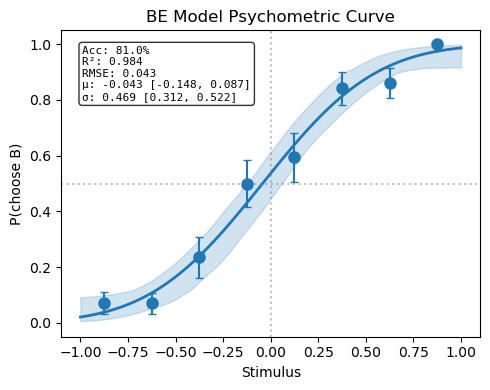

In [6]:
# Plot psychometric curve
fig, info = plot_psychometric(
    stimuli, choices,
    show_gof=True,
    show_params=True,
    n_bootstrap=100,
    title='BE Model Psychometric Curve'
)
plt.tight_layout()
plt.show()

---
# Part II: Burn-in Analysis

How does the model's experience level (burn-in) affect behaviour and parameter recovery?

## 4. Burn-in Effects on Behaviour

Compare naive (burn_in=0) vs expert (burn_in=1000+) behaviour.

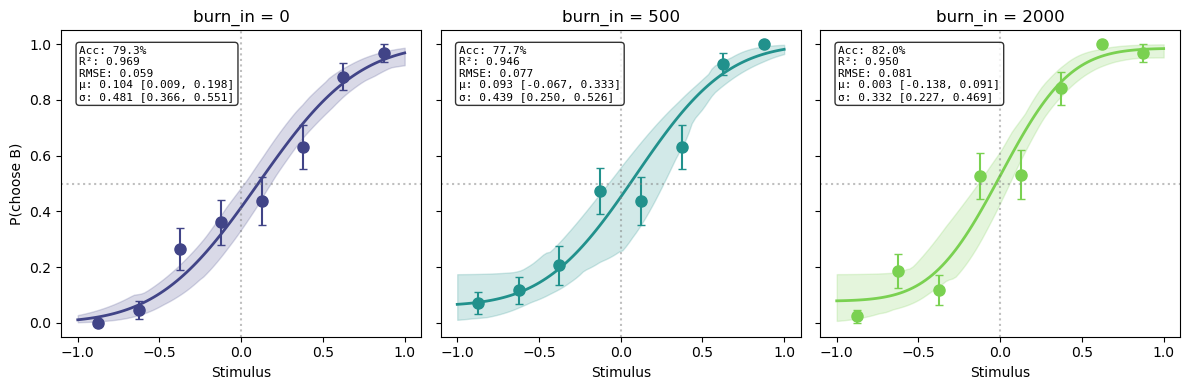


Metrics by burn-in:
 burn_in  accuracy    mu  sigma  r_squared
       0     0.793 0.104  0.481      0.969
     500     0.777 0.093  0.439      0.946
    2000     0.820 0.003  0.332      0.950


In [10]:
# Visualise psychometric curves at different burn-in levels
fig, gof_df = plot_psychometric_by_burn_in(
    params=TRUE_BE_PARAMS,
    burn_in_values=[0, 500, 2000],
    n_trials=N_TRIALS,
    show_gof=True,
    show_params=True,
    n_bootstrap=50
)
plt.show()

print("\nMetrics by burn-in:")
print(gof_df[['burn_in', 'accuracy', 'mu', 'sigma', 'r_squared']].round(3).to_string(index=False))

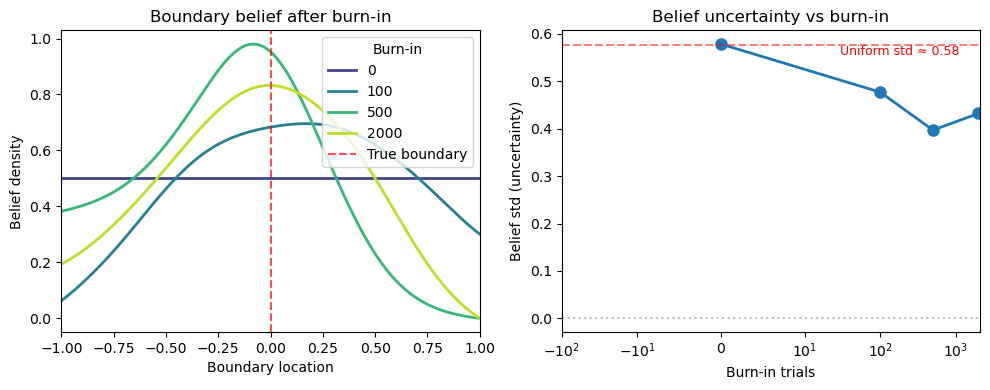

In [11]:
# Visualise belief distributions after different burn-in amounts
fig = plot_belief_after_burn_in(
    params=TRUE_BE_PARAMS,
    burn_in_values=[0, 100, 500, 2000]
)
plt.show()

## 5. Burn-in Effects on Parameter Recovery

Does the fitter correctly recover parameters when there's a burn-in mismatch?

In [12]:
# Run burn-in recovery analysis
print("Running burn-in recovery analysis...")
results_burnin = burn_in_recovery_analysis(
    true_params=TRUE_BE_PARAMS,
    burn_in_values=[0, 1000, 5000],
    n_trials=N_TRIALS,
    n_replicates=N_REPLICATES,
    fitter_burn_in=0,
    verbose=True
)

Running burn-in recovery analysis...

Testing burn_in = 0
  Replicate 1/10... OK
  Replicate 2/10... OK
  Replicate 3/10... OK
  Replicate 4/10... OK
  Replicate 5/10... OK
  Replicate 6/10... OK
  Replicate 7/10... OK
  Replicate 8/10... OK
  Replicate 9/10... OK
  Replicate 10/10... OK

Testing burn_in = 1000
  Replicate 1/10... OK
  Replicate 2/10... OK
  Replicate 3/10... OK
  Replicate 4/10... OK
  Replicate 5/10... OK
  Replicate 6/10... OK
  Replicate 7/10... OK
  Replicate 8/10... OK
  Replicate 9/10... OK
  Replicate 10/10... OK

Testing burn_in = 5000
  Replicate 1/10... OK
  Replicate 2/10... OK
  Replicate 3/10... OK
  Replicate 4/10... OK
  Replicate 5/10... OK
  Replicate 6/10... OK
  Replicate 7/10... OK
  Replicate 8/10... OK
  Replicate 9/10... OK
  Replicate 10/10... OK


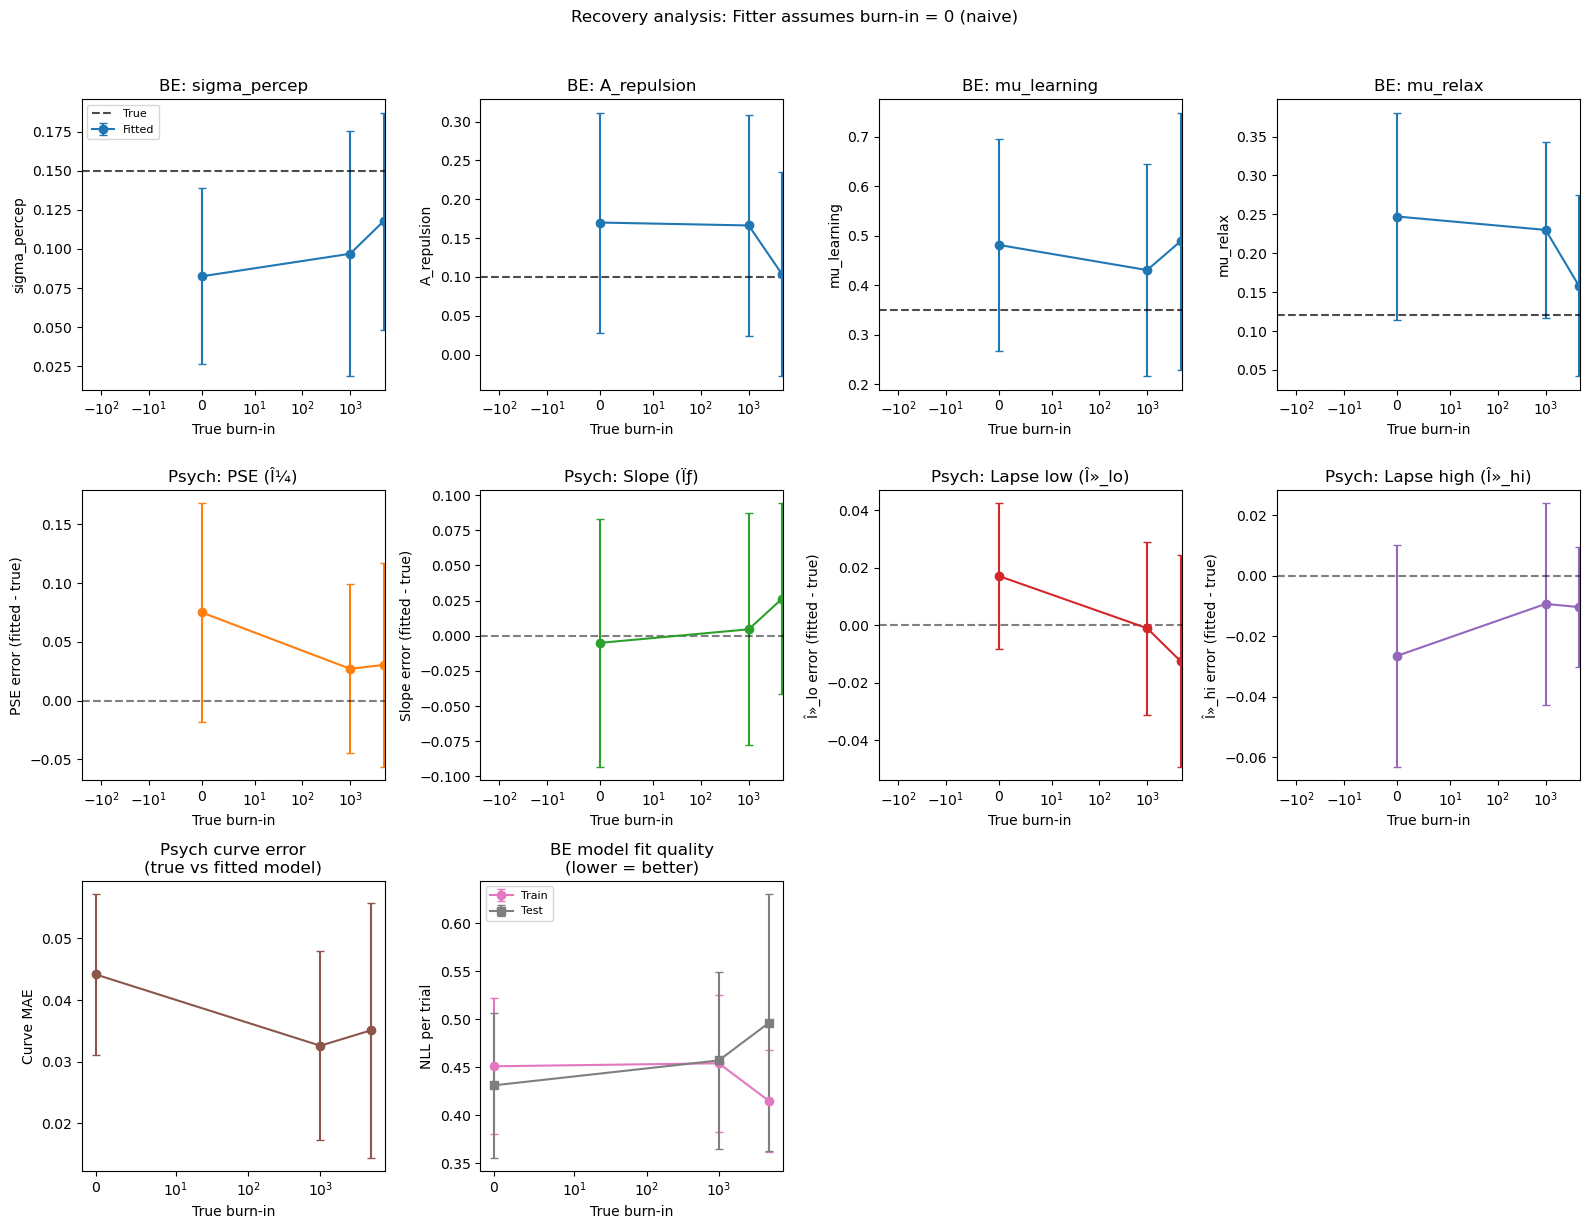

In [13]:
# Visualise recovery results
fig = plot_burn_in_recovery(results_burnin)
plt.tight_layout()
plt.show()

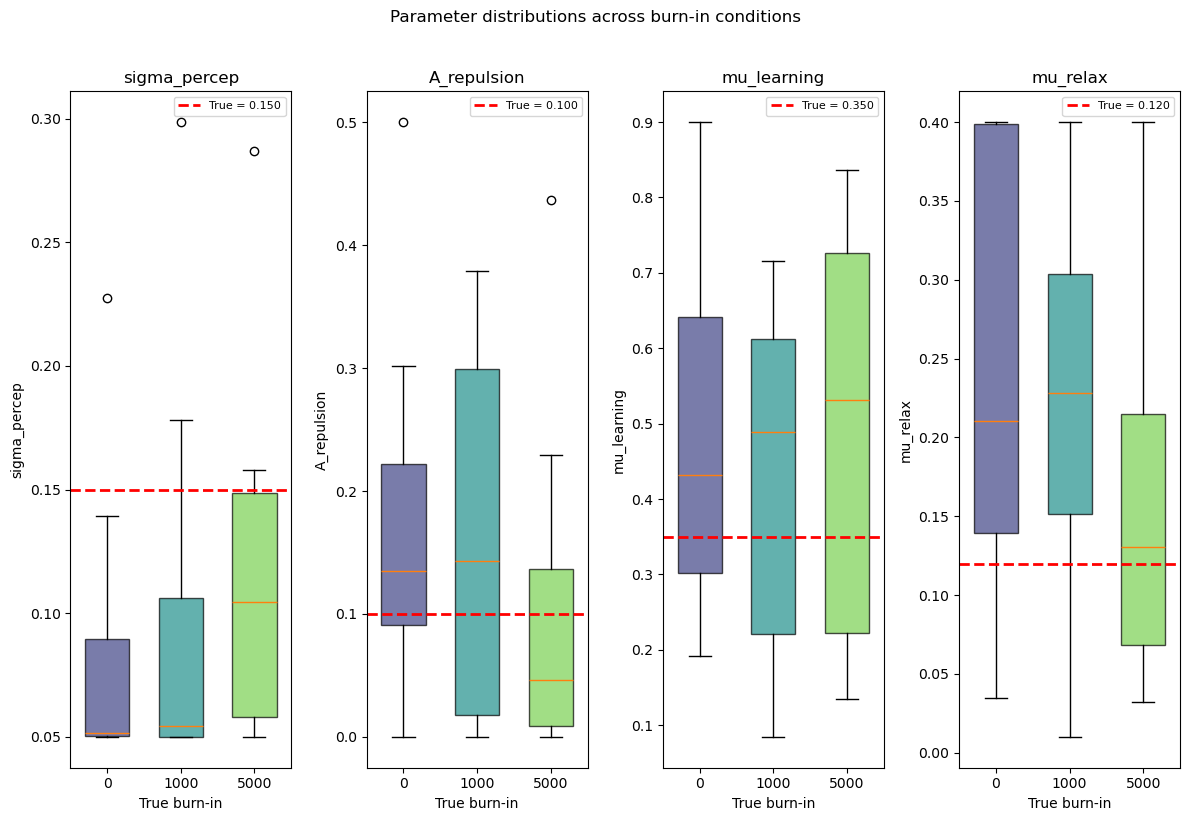

In [14]:
# Parameter distributions
fig = plot_burn_in_param_distributions(results_burnin)
plt.tight_layout()
plt.show()

In [15]:
# Summary statistics
df_burnin = burn_in_recovery_summary_stats(results_burnin)
print("\nBurn-in Recovery Summary:")
cols = ['burn_in', 'sigma_percep_bias', 'A_repulsion_bias', 
        'mu_learning_bias', 'mu_relax_bias', 'psych_curve_mae']
print(df_burnin[[c for c in cols if c in df_burnin.columns]].round(4).to_string(index=False))


Burn-in Recovery Summary:
 burn_in  sigma_percep_bias  A_repulsion_bias  mu_learning_bias  mu_relax_bias  psych_curve_mae
       0            -0.0675            0.0700            0.1318         0.1272           0.0442
    1000            -0.0531            0.0662            0.0809         0.1100           0.0326
    5000            -0.0322            0.0034            0.1390         0.0380           0.0351


In [16]:
# Key insight: Look at mu_learning bias as burn-in increases
print("\nKey finding - mu_learning bias by burn-in:")
for burn_in in results_burnin['config']['burn_in_values']:
    bias = results_burnin['param_recovery'][burn_in]['mu_learning']['mean_error']
    print(f"  burn_in={burn_in:5d}: bias = {bias:+.4f}")


Key finding - mu_learning bias by burn-in:
  burn_in=    0: bias = +0.1318
  burn_in= 1000: bias = +0.0809
  burn_in= 5000: bias = +0.1390


---
# Part III: Parameter Sensitivity

How do individual BE parameters affect behaviour and recovery?

## 6. Single Parameter Sweeps (Behaviour)

Sweep one parameter while holding others fixed.

In [17]:
# Sweep sigma_percep
print("Sweeping sigma_percep...")
results_sigma_beh = be_param_behaviour_sweep(
    base_params=TRUE_BE_PARAMS,
    sweep_param='sigma_percep',
    sweep_values=[0.05, 0.1, 0.15, 0.2, 0.3, 0.4],
    burn_in_values=[0, 1000],
    n_trials=N_TRIALS,
    n_replicates=N_REPLICATES,
    verbose=True
)

Sweeping sigma_percep...

sigma_percep = 0.05
  burn_in = 0... Acc=0.810±0.016, R²=0.980
  burn_in = 1000... Acc=0.818±0.019, R²=0.978

sigma_percep = 0.1
  burn_in = 0... Acc=0.812±0.019, R²=0.973
  burn_in = 1000... Acc=0.819±0.020, R²=0.983

sigma_percep = 0.15
  burn_in = 0... Acc=0.802±0.021, R²=0.975
  burn_in = 1000... Acc=0.805±0.022, R²=0.969

sigma_percep = 0.2
  burn_in = 0... Acc=0.795±0.021, R²=0.962
  burn_in = 1000... Acc=0.802±0.017, R²=0.980

sigma_percep = 0.3
  burn_in = 0... Acc=0.789±0.016, R²=0.977
  burn_in = 1000... Acc=0.775±0.024, R²=0.976

sigma_percep = 0.4
  burn_in = 0... Acc=0.751±0.033, R²=0.961
  burn_in = 1000... Acc=0.767±0.025, R²=0.963


In [18]:
# Summary
df_sigma_beh = be_param_sweep_summary(results_sigma_beh, 'behaviour')
print("\nσ_percep effect on behaviour:")
print(df_sigma_beh[['sigma_percep', 'burn_in', 'accuracy_mean', 
                    'accuracy_p_vs_chance', 'r_squared_mean', 'sigma_mean']].round(4).to_string(index=False))


σ_percep effect on behaviour:
 sigma_percep  burn_in  accuracy_mean  accuracy_p_vs_chance  r_squared_mean  sigma_mean
         0.05        0         0.8103                   0.0          0.9799      0.4226
         0.05     1000         0.8180                   0.0          0.9780      0.4309
         0.10        0         0.8117                   0.0          0.9725      0.4430
         0.10     1000         0.8187                   0.0          0.9833      0.4304
         0.15        0         0.8020                   0.0          0.9753      0.4385
         0.15     1000         0.8047                   0.0          0.9689      0.4307
         0.20        0         0.7950                   0.0          0.9623      0.4717
         0.20     1000         0.8020                   0.0          0.9805      0.4334
         0.30        0         0.7887                   0.0          0.9769      0.4332
         0.30     1000         0.7753                   0.0          0.9763      0.5114
 

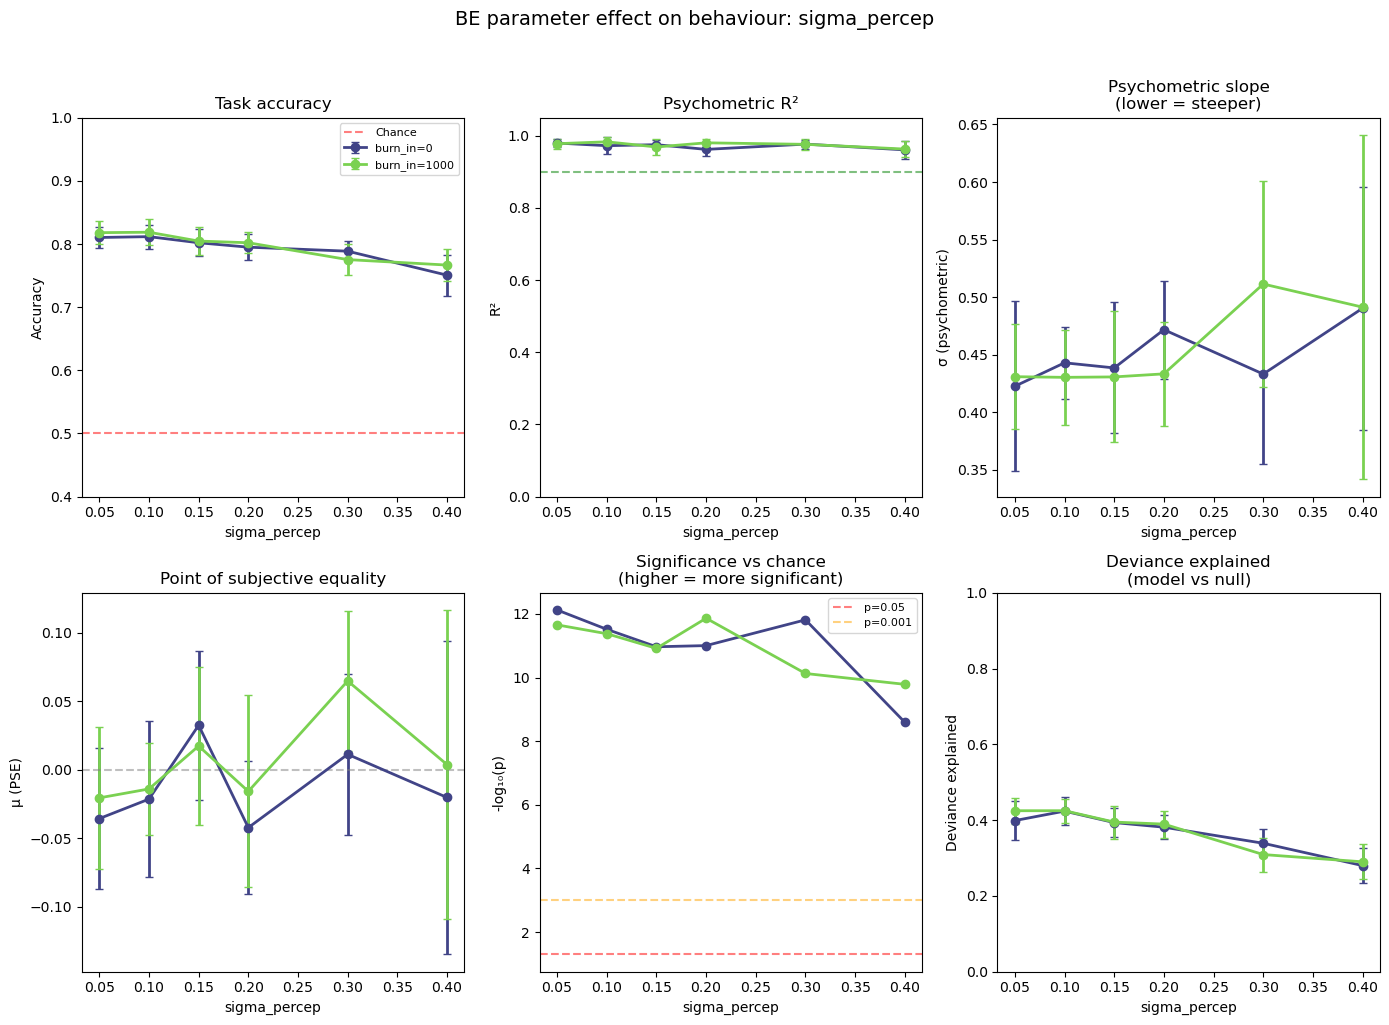

In [19]:
# Plot behaviour metrics
fig = plot_be_param_behaviour_sweep(results_sigma_beh)
plt.tight_layout()
plt.show()

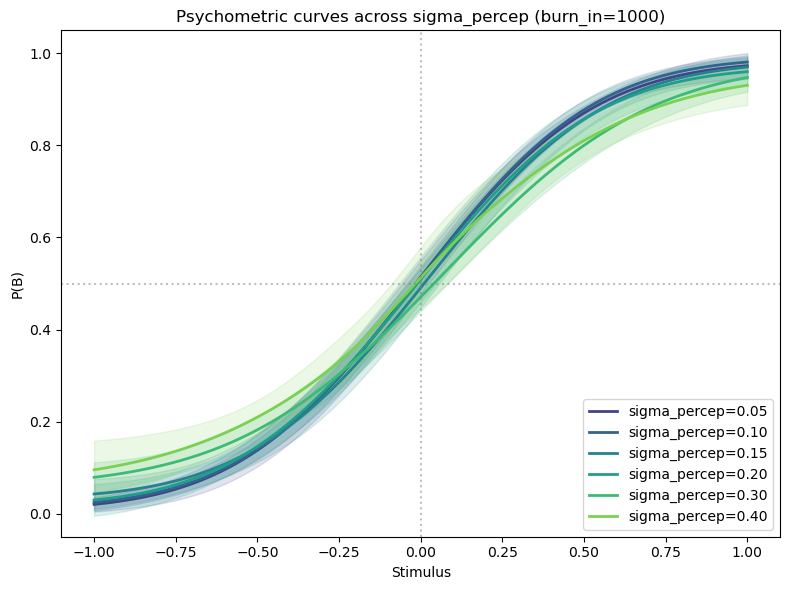

In [20]:
# Psychometric curves - overlay
fig = plot_behaviour_sweep_psychometrics_overlay(results_sigma_beh, burn_in=1000)
plt.show()

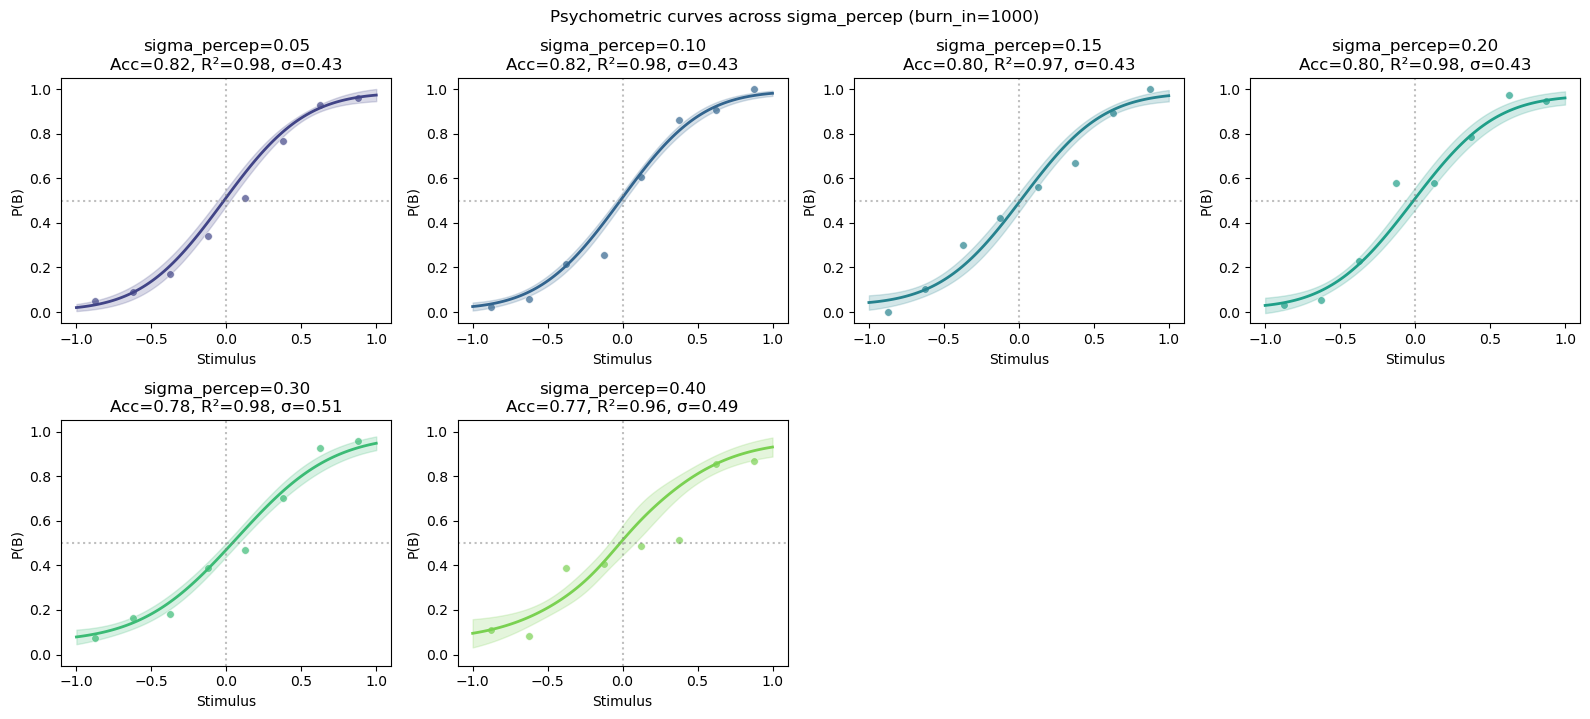

In [21]:
# Psychometric curves - grid
fig = plot_behaviour_sweep_psychometrics(results_sigma_beh, burn_in=1000)
plt.show()

## 7. Single Parameter Sweeps (Recovery)

How does the true parameter value affect recovery accuracy?

In [ ]:
# Sweep sigma_percep - recovery analysis
print("Sweeping sigma_percep for recovery...")
results_sigma_rec = be_param_recovery_sweep(
    base_params=TRUE_BE_PARAMS,
    sweep_param='sigma_percep',
    sweep_values=[0.05, 0.1, 0.15, 0.2, 0.3],
    burn_in_values=[0, 1000],
    n_trials=N_TRIALS,
    n_replicates=N_REPLICATES,
    fitter_burn_in=0,
    verbose=True
)

In [ ]:
# Summary
df_sigma_rec = be_param_sweep_summary(results_sigma_rec, 'recovery')
print("\nσ_percep effect on recovery:")
print(df_sigma_rec[['sigma_percep', 'burn_in', 'sigma_percep_bias', 
                    'mu_learning_bias', 'train_nll_mean']].round(4).to_string(index=False))

In [ ]:
# Plot recovery
fig = plot_be_param_recovery_sweep(results_sigma_rec)
plt.tight_layout()
plt.show()

## 8. Joint Parameter Effects (2D)

Examine interactions between pairs of parameters.

In [24]:
# Joint sweep: sigma_percep × mu_learning
print("Running joint sweep: sigma_percep × mu_learning...")
results_joint = be_param_joint_sweep(
    base_params=TRUE_BE_PARAMS,
    param1='sigma_percep',
    param1_values=[0.1, 0.15, 0.2, 0.3],
    param2='mu_learning',
    param2_values=[0.2, 0.35, 0.5],
    burn_in=1000,
    n_trials=N_TRIALS,
    n_replicates=5,
    verbose=True
)

Running joint sweep: sigma_percep × mu_learning...
  [12/12] sigma_percep=0.300, mu_learning=0.500
Done!


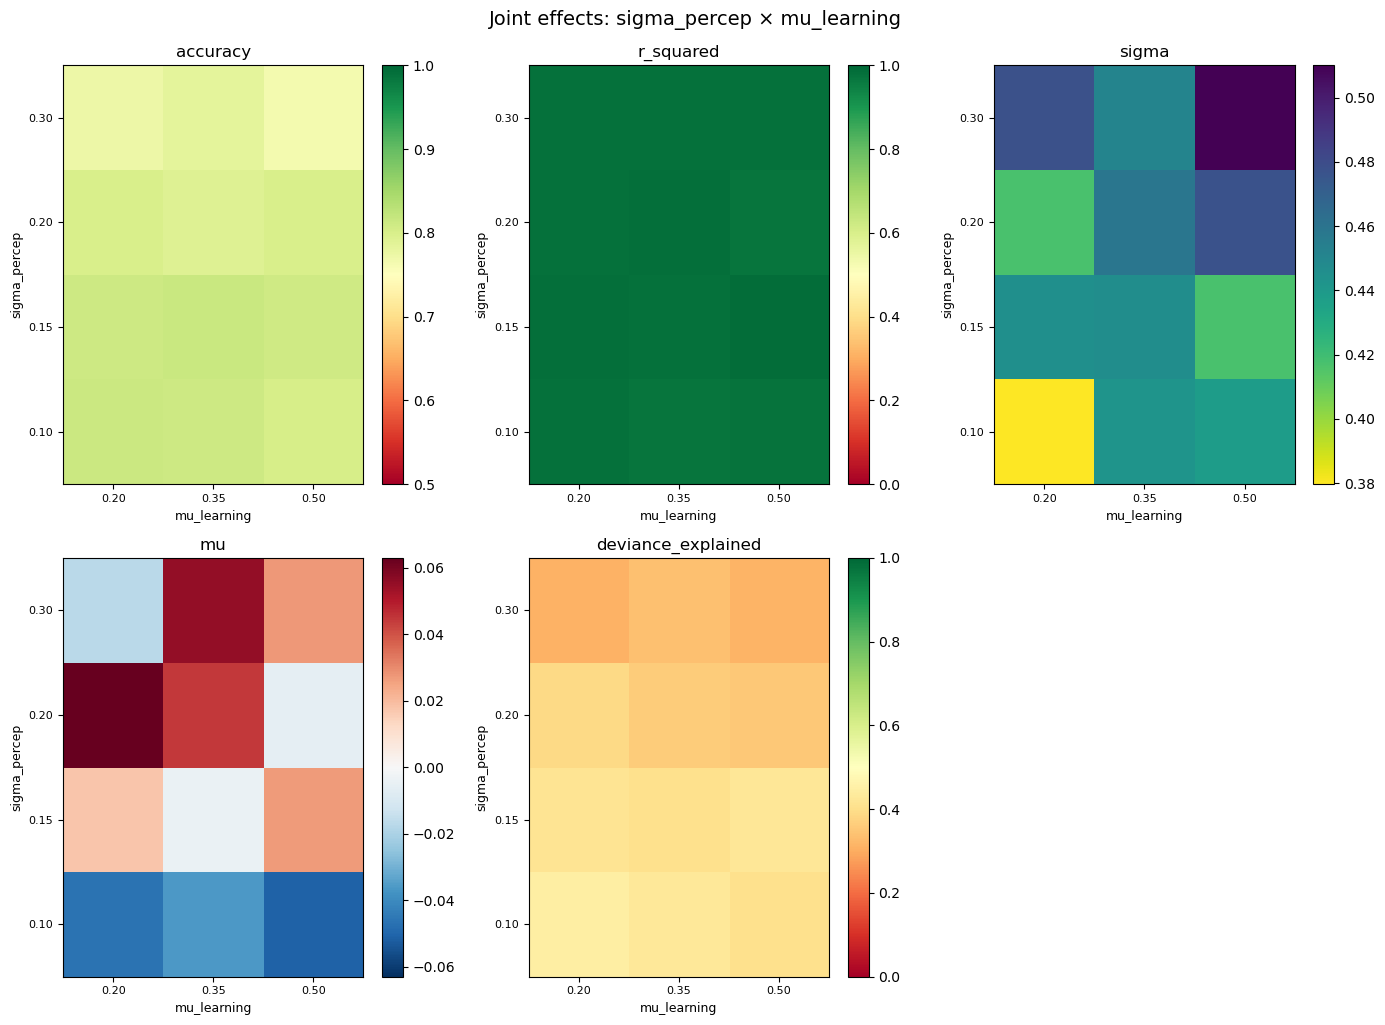

In [25]:
# Heatmaps
fig = plot_joint_sweep_all_metrics(results_joint)
plt.show()

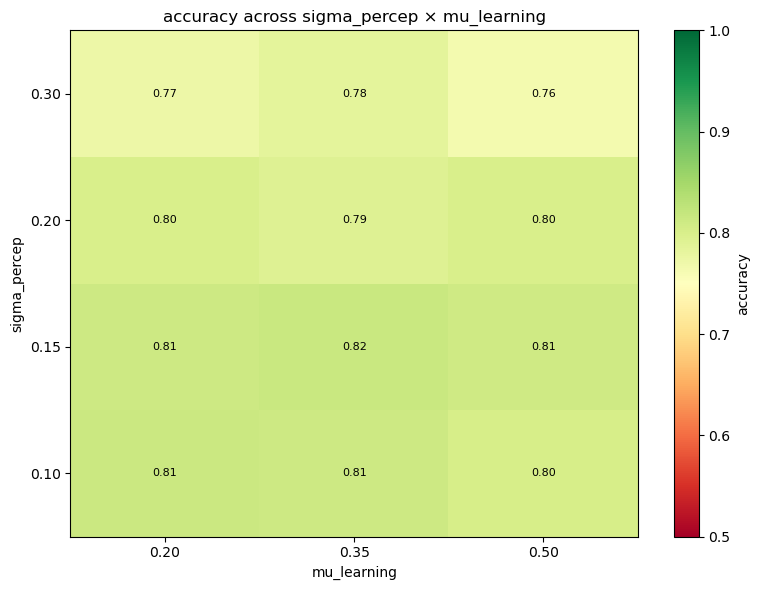

In [26]:
# Accuracy heatmap
fig = plot_joint_sweep_heatmap(results_joint, metric='accuracy', annotate=True)
plt.show()

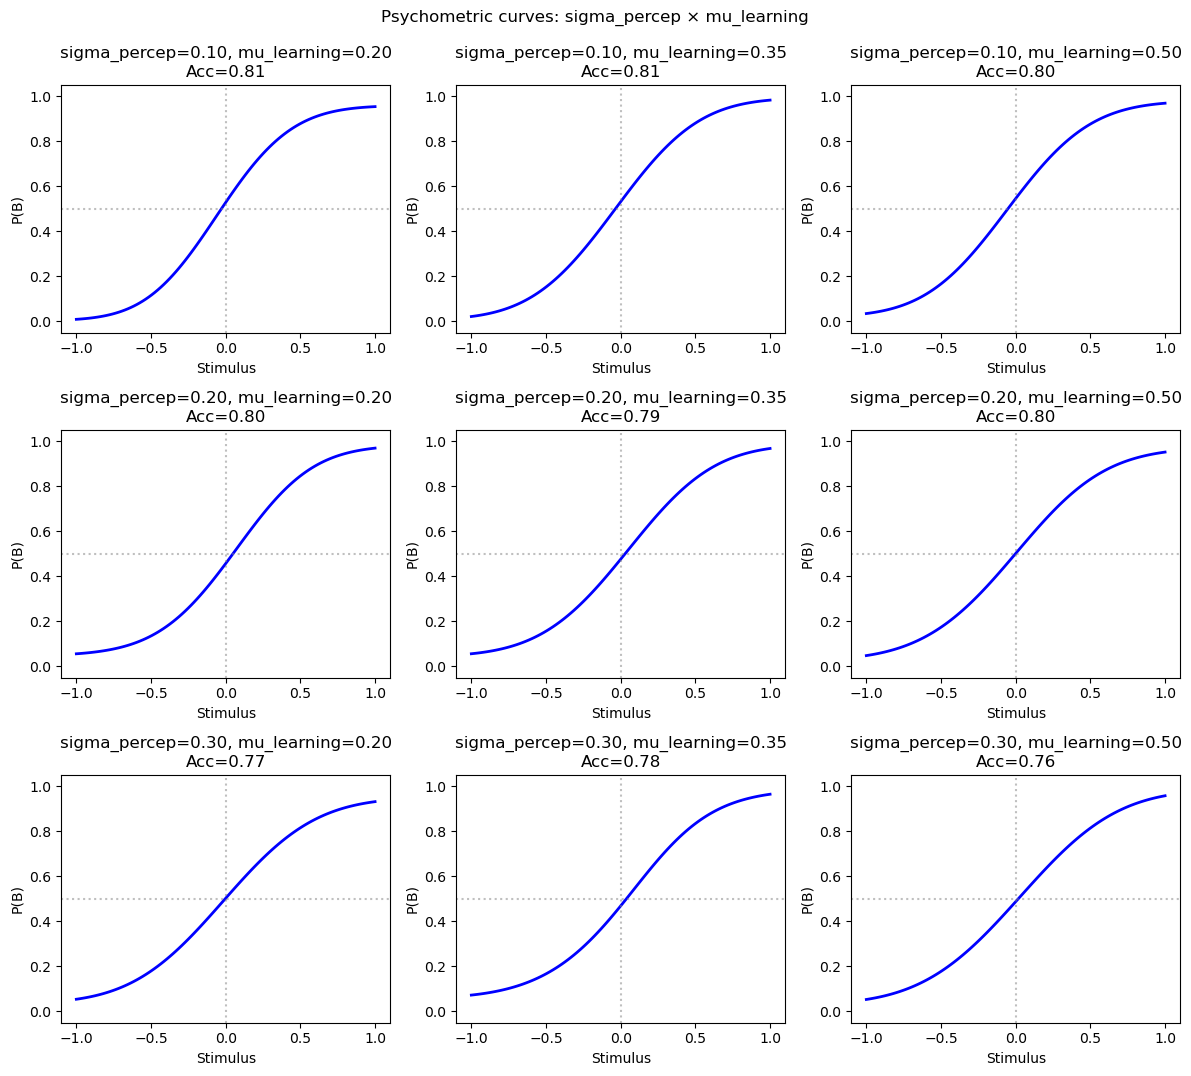

In [27]:
# Psychometric curves at grid points
fig = plot_joint_sweep_psychometrics(results_joint)
plt.show()

## 9. Sobol Sensitivity Analysis

Comprehensive analysis of all parameters simultaneously.

**Key outputs:**
- **S1 (first-order)**: Effect of parameter alone
- **ST (total-order)**: Effect including all interactions
- **ST - S1 gap**: Indicates interaction strength

In [4]:
# Sobol analysis for behaviour
# NOTE: Takes 10-60 minutes depending on settings

print("Running Sobol sensitivity analysis...")
print("This may take 10-30 minutes...\n")

results_sobol = sobol_be_behaviour(
    param_ranges={
        'sigma_percep': (0.05, 0.4),
        'A_repulsion': (0.0, 0.25),
        'mu_learning': (0.1, 0.5),
        'mu_relax': (0.05, 0.25),
    },
    burn_in_values=[0, 500, 1000, 2000],
    n_sobol=64,           # Use 256 for publication
    n_replicates=3,       # Use 5 for publication
    n_trials=N_TRIALS,
    verbose=True
)

Running Sobol sensitivity analysis...
This may take 10-30 minutes...

Sobol Analysis Setup:
  Parameters: ['sigma_percep', 'A_repulsion', 'mu_learning', 'mu_relax', 'burn_in']
  n_sobol=64 → 768 samples
  n_replicates=3
  Total simulations: 2304

Running 768 parameter combinations...
  100/768 (13%)
  200/768 (26%)
  300/768 (39%)
  400/768 (52%)
  500/768 (65%)
  600/768 (78%)
  700/768 (91%)

Computing Sobol indices...
Done!

Summary (first output):
   parameter        S1  S1_conf       ST  ST_conf
sigma_percep  0.501448 0.264068 0.824899 0.294729
 A_repulsion  0.021822 0.199005 0.259449 0.092968
 mu_learning  0.154581 0.256416 0.340701 0.113066
    mu_relax  0.130672 0.223404 0.378728 0.125371
     burn_in -0.056617 0.192998 0.301765 0.115189


In [5]:
# Accuracy sensitivity
print("\nAccuracy sensitivity indices:")
print(results_sobol.sensitivity['accuracy'].to_string(index=False))

print("\nMost influential parameters:")
print(results_sobol.most_influential('accuracy'))


Accuracy sensitivity indices:
   parameter        S1  S1_conf       ST  ST_conf
sigma_percep  0.501448 0.264068 0.824899 0.294729
 A_repulsion  0.021822 0.199005 0.259449 0.092968
 mu_learning  0.154581 0.256416 0.340701 0.113066
    mu_relax  0.130672 0.223404 0.378728 0.125371
     burn_in -0.056617 0.192998 0.301765 0.115189

Most influential parameters:
['sigma_percep', 'mu_relax', 'mu_learning', 'burn_in', 'A_repulsion']


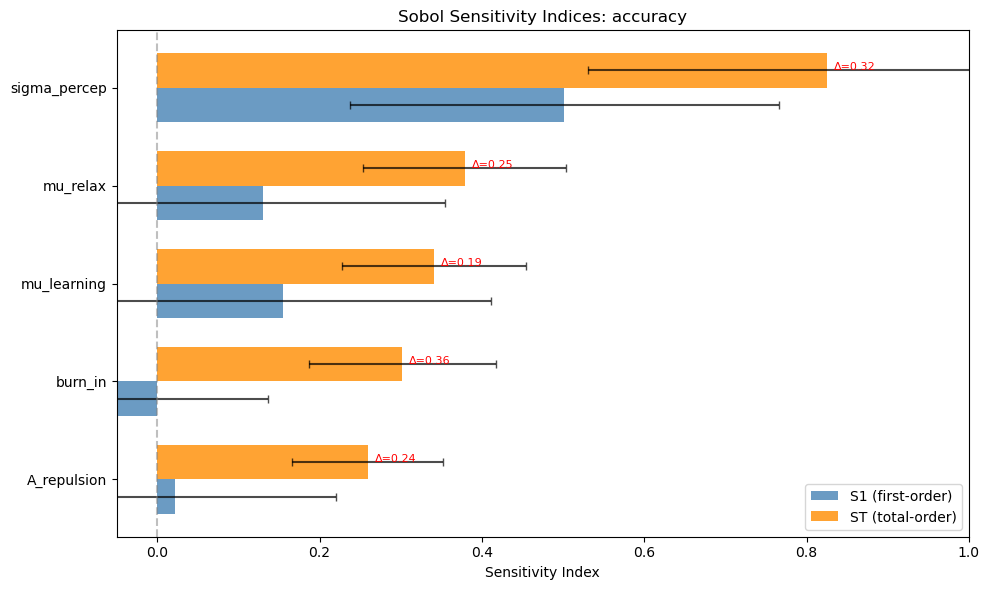

In [6]:
# Sobol indices bar chart
fig = plot_sobol_indices(results_sobol, 'accuracy')
plt.show()

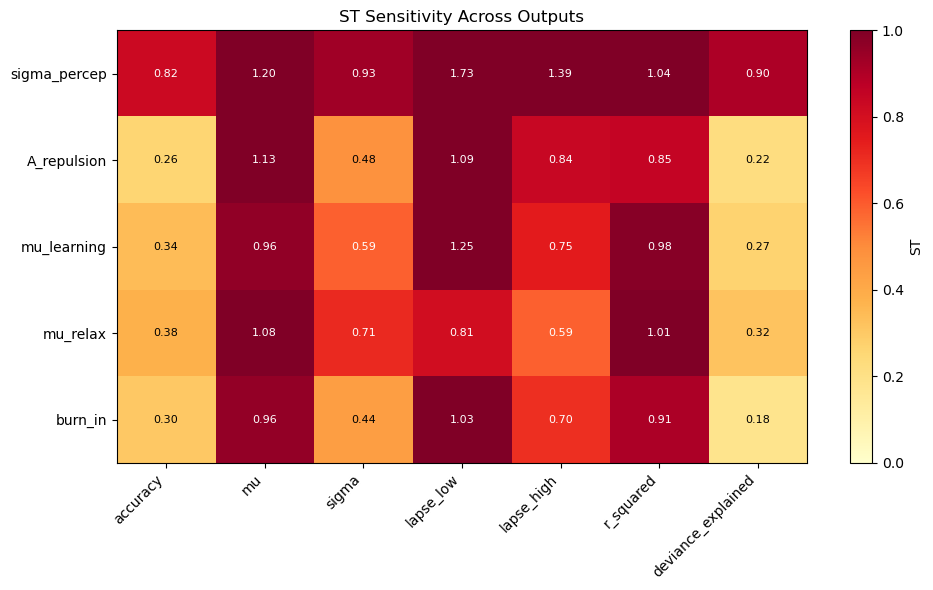

In [7]:
# Summary heatmap
fig = plot_sobol_summary_heatmap(results_sobol)
plt.show()

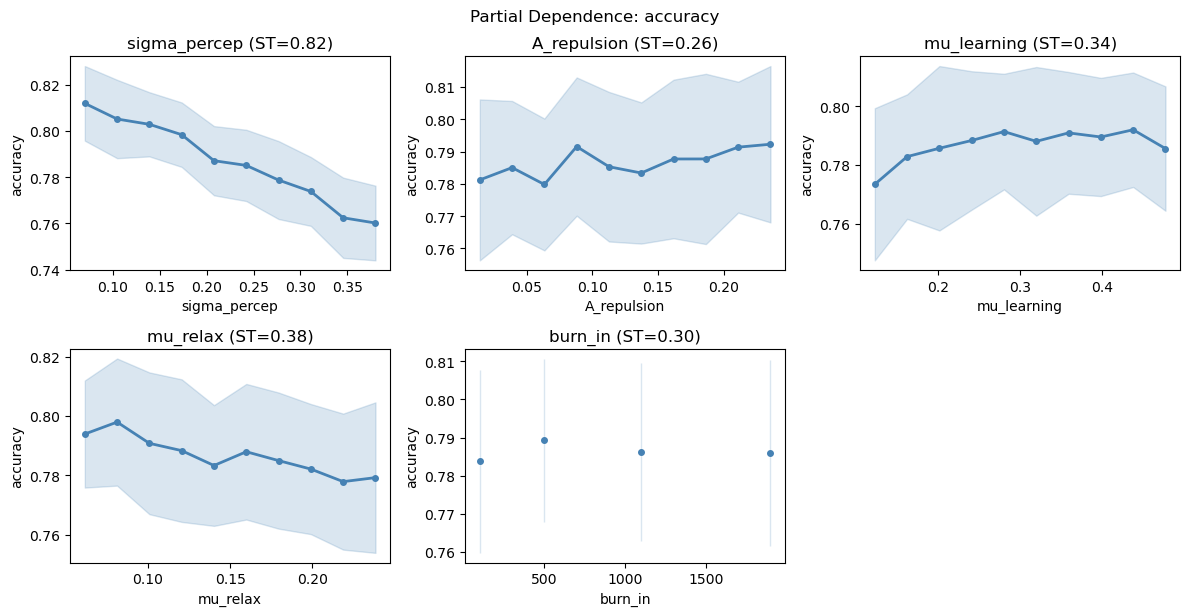

In [8]:
# Partial dependence plots
fig = plot_partial_dependence_grid(results_sobol, 'accuracy')
plt.show()

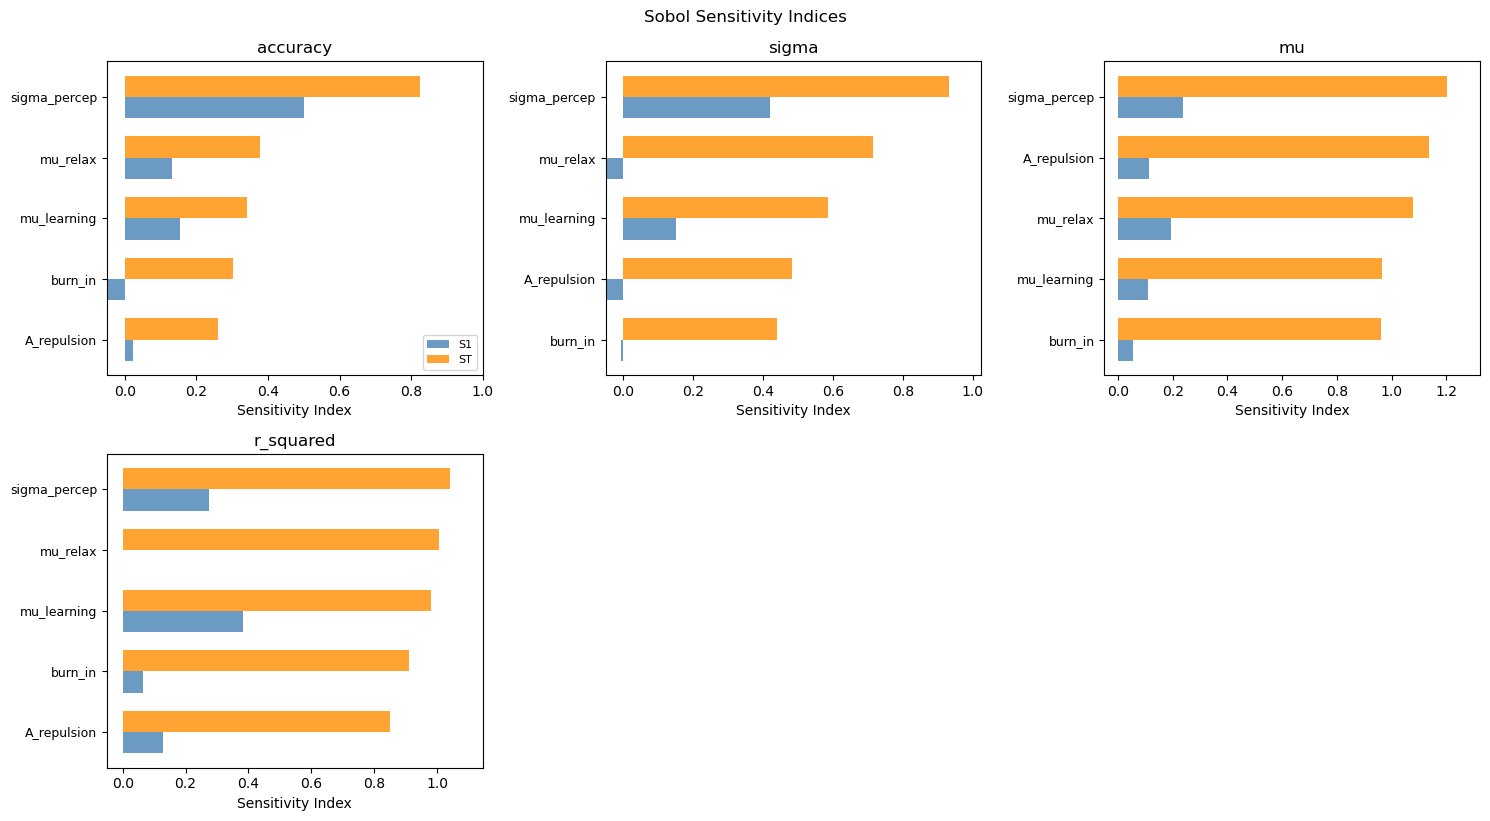

In [9]:
# Multiple outputs comparison
fig = plot_sobol_indices_multi(results_sobol, 
                               outputs=['accuracy', 'sigma', 'mu', 'r_squared'])
plt.show()

---
# Part IV: MixedAgent Analysis

The MixedAgent combines BE model with heuristic strategies:

$$P(B) = \alpha \times P(B|BE) + (1-\alpha) \times P(B|heuristics)$$

Where heuristics include: side bias, win-stay, lose-shift, random.

## 10. MixedAgent Simulation

Simulate behaviour at different α levels.

In [10]:
# Simulate at different alpha levels
alpha_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

print("Simulating MixedAgent at different α levels...\n")

stimuli, categories, rng = generate_stimuli(n_trials=N_TRIALS, seed=SEED)

mixed_results = []
for alpha in alpha_values:
    agent = MixedAgent(
        **TRUE_BE_PARAMS,
        alpha=alpha,
        **HEURISTIC_PARAMS,
        burn_in=1000,
        burn_in_seed=SEED
    )
    
    choices, p_B = agent.simulate_session(stimuli, categories, rng=np.random.default_rng(SEED))
    
    accuracy = np.mean(choices == categories)
    psych = fit_psychometric(stimuli, choices)
    gof = compute_psychometric_gof(stimuli, choices, psych)
    
    mixed_results.append({
        'alpha': alpha,
        'accuracy': accuracy,
        'r_squared': gof['r_squared'],
        'sigma': psych['sigma'],
        'mu': psych['mu'],
        'lapse_low': psych['lapse_low'],
        'lapse_high': psych['lapse_high']
    })
    
    print(f"α={alpha:.1f}: Acc={accuracy:.2f}, R²={gof['r_squared']:.2f}, σ={psych['sigma']:.2f}")

df_mixed_sim = pd.DataFrame(mixed_results)

Simulating MixedAgent at different α levels...

α=0.0: Acc=0.46, R²=-0.05, σ=2.00
α=0.2: Acc=0.52, R²=0.70, σ=0.57
α=0.4: Acc=0.56, R²=0.74, σ=0.61
α=0.6: Acc=0.62, R²=0.89, σ=0.46
α=0.8: Acc=0.69, R²=0.91, σ=0.45
α=1.0: Acc=0.74, R²=0.96, σ=0.63


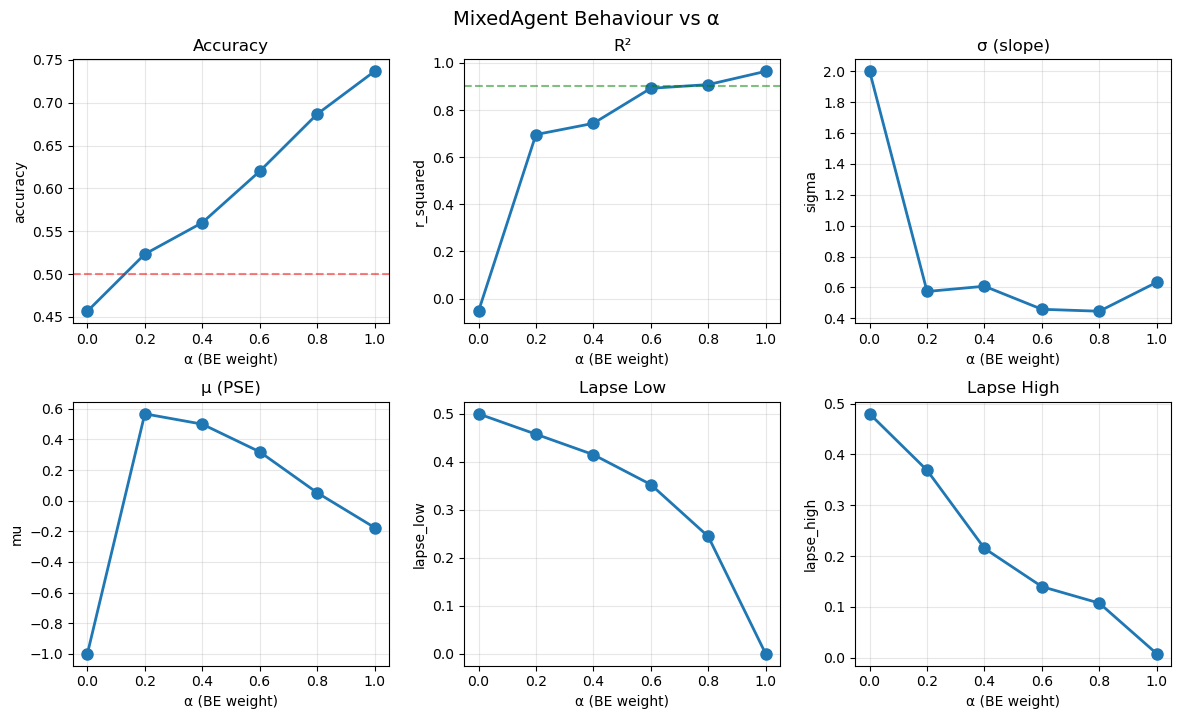

In [11]:
# Plot metrics vs alpha
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

metrics = ['accuracy', 'r_squared', 'sigma', 'mu', 'lapse_low', 'lapse_high']
titles = ['Accuracy', 'R²', 'σ (slope)', 'μ (PSE)', 'Lapse Low', 'Lapse High']

for ax, metric, title in zip(axes.flatten(), metrics, titles):
    ax.plot(df_mixed_sim['alpha'], df_mixed_sim[metric], 'o-', linewidth=2, markersize=8)
    ax.set_xlabel('α (BE weight)')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

# Add reference lines
axes[0, 0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
axes[0, 1].axhline(0.9, color='green', linestyle='--', alpha=0.5, label='Good fit')

plt.tight_layout()
plt.suptitle('MixedAgent Behaviour vs α', y=1.02, fontsize=14)
plt.show()

## 11. BE Recovery from MixedAgent Data

Can we recover the true BE parameters when behaviour is contaminated by heuristics?

In [12]:
# Run mixed agent recovery analysis
print("Running MixedAgent recovery analysis...")
results_mixed_rec = mixed_agent_recovery_analysis(
    true_be_params=TRUE_BE_PARAMS,
    alpha_values=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    heuristic_params=HEURISTIC_PARAMS,
    n_trials=N_TRIALS,
    n_replicates=N_REPLICATES,
    agent_burn_in=1000,
    fitter_burn_in=0,
    verbose=True
)

Running MixedAgent recovery analysis...

Testing α = 0.00
  Replicate 1/10... 

KeyboardInterrupt: 

In [ ]:
# Summary
df_mixed_rec = mixed_agent_recovery_summary_stats(results_mixed_rec)
print("\nMixedAgent Recovery Summary:")
cols = ['alpha', 'accuracy_mean', 'r_squared_mean', 
        'sigma_percep_bias', 'mu_learning_bias']
print(df_mixed_rec[[c for c in cols if c in df_mixed_rec.columns]].round(4).to_string(index=False))

In [ ]:
# Recovery visualisation
fig = plot_mixed_agent_recovery(results_mixed_rec)
plt.tight_layout()
plt.show()

In [ ]:
# Parameter distributions
fig = plot_mixed_agent_param_distributions(results_mixed_rec)
plt.tight_layout()
plt.show()

In [ ]:
# Bias heatmap
fig = plot_mixed_agent_bias_heatmap(results_mixed_rec)
plt.tight_layout()
plt.show()

### 11.1 MixedAgent × BE Parameter Sweep

How does σ_percep affect behaviour/recovery at different α levels?

In [ ]:
# Mixed agent sweep: sigma_percep × alpha
print("Running MixedAgent × sigma_percep sweep...")
results_mixed_sweep = mixed_agent_be_param_sweep(
    base_be_params=TRUE_BE_PARAMS,
    sweep_param='sigma_percep',
    sweep_values=[0.1, 0.15, 0.2, 0.3],
    alpha_values=[0.0, 0.3, 0.6, 1.0],
    heuristic_params=HEURISTIC_PARAMS,
    burn_in_values=[500, 2000],
    n_trials=N_TRIALS,
    n_replicates=N_REPLICATES,
    fitter_burn_in=0,
    verbose=True
)

In [ ]:
# Summary table
df_mixed_sweep = mixed_agent_be_param_sweep_summary(results_mixed_sweep)
print(df_mixed_sweep[['sigma_percep', 'burn_in', 'alpha', 'accuracy', 'r_squared']].round(3))

In [ ]:
# Heatmaps
fig = plot_mixed_agent_be_param_sweep(results_mixed_sweep, metric='accuracy')
plt.show()

fig = plot_mixed_agent_be_param_sweep(results_mixed_sweep, metric='r_squared')
plt.show()

## 12. Schema Detection Thresholds

What metrics best distinguish BE-dominated from heuristic-dominated behaviour?

In [ ]:
# Interpretation guide
print("""
SCHEMA DETECTION GUIDE
======================

Metric thresholds for detecting BE-dominated behaviour:

| Metric              | Heuristic-dominated | Transitional | BE-dominated |
|---------------------|--------------------:|-------------:|-------------:|
| R²                  |           < 0.5     |   0.5 - 0.85 |     > 0.85   |
| Accuracy            |           < 0.55    |  0.55 - 0.70 |     > 0.70   |
| Psychometric σ      |           > 1.0     |   0.5 - 1.0  |     < 0.5    |
| Deviance explained  |           < 0.2     |   0.2 - 0.4  |     > 0.4    |

α estimation from behaviour:
- α < 0.3:  Heuristic-dominated, unreliable parameter recovery
- α 0.3-0.7: Transitional, mixed behaviour
- α > 0.7:  BE-dominated, reasonable parameter recovery
""")

In [ ]:
# Visualise thresholds
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R² vs alpha
ax = axes[0]
ax.plot(df_mixed_sim['alpha'], df_mixed_sim['r_squared'], 'o-', linewidth=2, markersize=10)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Heuristic threshold')
ax.axhline(0.85, color='green', linestyle='--', alpha=0.7, label='BE threshold')
ax.axhspan(0.5, 0.85, alpha=0.1, color='orange', label='Transitional')
ax.set_xlabel('α (BE weight)', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title('R² vs α', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy vs alpha
ax = axes[1]
ax.plot(df_mixed_sim['alpha'], df_mixed_sim['accuracy'], 'o-', linewidth=2, markersize=10)
ax.axhline(0.5, color='black', linestyle=':', alpha=0.5, label='Chance')
ax.axhline(0.55, color='red', linestyle='--', alpha=0.7, label='Heuristic threshold')
ax.axhline(0.70, color='green', linestyle='--', alpha=0.7, label='BE threshold')
ax.set_xlabel('α (BE weight)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy vs α', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Summary

## Key Findings

### Parameter Effects on Behaviour
1. **σ_percep** dominates accuracy - higher noise → worse performance
2. **μ_learning** affects adaptation speed and psychometric slope
3. **burn_in** sharpens initial belief but has modest effect on steady-state
4. **A_repulsion** and **μ_relax** have smaller effects

### Parameter Recovery
1. Recovery improves with more trials and better behaviour (higher R²)
2. Burn-in mismatch causes systematic biases in μ_learning
3. Parameter identifiability issues exist even with perfect data

### MixedAgent/Schema Detection
1. R² is the best single metric for detecting BE-dominated behaviour
2. α > 0.6-0.7 needed for reliable parameter recovery
3. Heuristic contamination causes systematic biases in all parameters

---